# AutoStream LeadIQ

## AI-Powered Conversational Lead Qualification System for SaaS Businesses

### AAI-510 Final Project


---

This project develops an AI-powered lead qualification system that combines conversational AI with machine learning-based lead scoring. The objective is to help SaaS businesses identify high-value prospects and prioritize sales efforts using predictive analytics.

## Github repository link :
https://github.com/BiswalSoura/social-to-lead-agent.git

# 1. Business Understanding

## Problem Statement

SaaS companies receive large volumes of leads from websites, chatbots, marketing campaigns, and social media channels. Sales teams often spend significant effort following up on leads that never convert into paying customers.

This creates inefficiencies, increases acquisition costs, and reduces overall sales productivity.

## Business Objective

The goal of this project is to build a machine learning model capable of predicting whether a lead will convert into a customer. The model will support lead prioritization and improve sales decision-making.

The final solution is integrated conceptually with the AutoStream LeadIQ conversational AI platform.

# 2. Data Understanding

The dataset contains information about prospective customers, their engagement behavior, demographic attributes, marketing sources, and conversion outcomes.

The target variable is:

- Converted
  - 1 = Converted Lead
  - 0 = Not Converted

In [ ]:
from pathlib import Path
import pandas as pd

csv_path = Path("data/raw/Lead Scoring.csv")

if not csv_path.exists():
    csv_path = Path("../data/raw/Lead Scoring.csv")

df = pd.read_csv(csv_path)


print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [5]:
print("Shape:", df.shape)

print("\nConverted Distribution:")
print(df["Converted"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Shape: (9240, 37)

Converted Distribution:
Converted
0    5679
1    3561
Name: count, dtype: int64

Missing Values:
Lead Quality                                     4767
Asymmetrique Activity Index                      4218
Asymmetrique Profile Score                       4218
Asymmetrique Activity Score                      4218
Asymmetrique Profile Index                       4218
Tags                                             3353
Lead Profile                                     2709
What matters most to you in choosing a course    2709
What is your current occupation                  2690
Country                                          2461
How did you hear about X Education               2207
Specialization                                   1438
City                                             1420
Page Views Per Visit                              137
TotalVisits                                       137
Last Activity                                     103
Lead Source         

In [6]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [7]:
print("Shape:", df.shape)

Shape: (9240, 37)


### Initial Observations

The dataset contains 9,240 records and 37 features. These features describe lead acquisition channels, website engagement behavior, demographic information, and lead quality indicators.

The dataset will be analyzed further to identify missing values, feature distributions, and relationships with lead conversion outcomes.

# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand the structure of the dataset, identify patterns, detect anomalies, and evaluate relationships between features and the target variable.

The primary objective of this analysis is to determine which factors are associated with lead conversion and to guide feature selection and model development.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)
sns.set_style("whitegrid")

## 3.1 Target Variable Distribution

Before building predictive models, it is important to understand the distribution of the target variable (Converted).

This helps determine whether the dataset is balanced and whether any special handling for class imbalance may be required.

In [9]:
df["Converted"].value_counts()

Converted
0    5679
1    3561
Name: count, dtype: int64

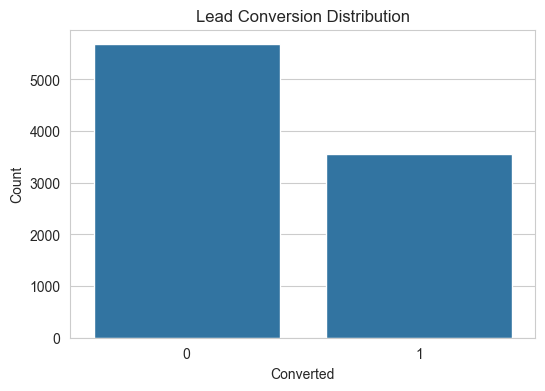

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Converted"
)

plt.title("Lead Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Count")

plt.show()

### Interpretation

The dataset contains both converted and non-converted leads. The distribution appears reasonably balanced, reducing concerns about severe class imbalance.

This is advantageous because machine learning models can learn meaningful patterns without requiring aggressive resampling techniques.

## 3.2 Missing Value Analysis

Missing values can negatively affect model performance and must be identified before feature engineering and model training.

The following analysis identifies the features with the highest percentage of missing data.

In [11]:
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_values.head(20)

Lead Quality                                     4767
Asymmetrique Activity Index                      4218
Asymmetrique Profile Score                       4218
Asymmetrique Activity Score                      4218
Asymmetrique Profile Index                       4218
Tags                                             3353
Lead Profile                                     2709
What matters most to you in choosing a course    2709
What is your current occupation                  2690
Country                                          2461
How did you hear about X Education               2207
Specialization                                   1438
City                                             1420
Page Views Per Visit                              137
TotalVisits                                       137
Last Activity                                     103
Lead Source                                        36
Receive More Updates About Our Courses              0
I agree to pay the amount th

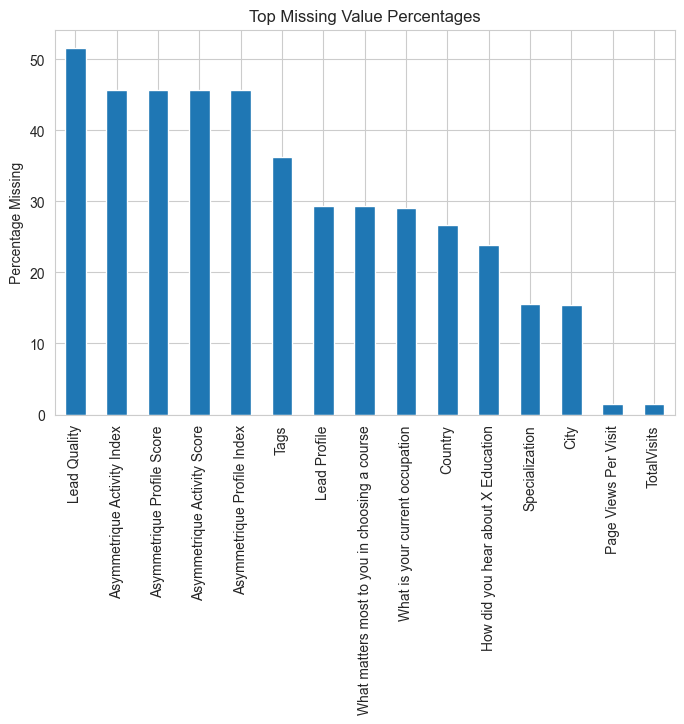

In [12]:
missing_percent = (
    df.isnull().mean()*100
).sort_values(ascending=False)

missing_percent.head(15).plot(
    kind="bar"
)

plt.title("Top Missing Value Percentages")
plt.ylabel("Percentage Missing")
plt.show()

### Interpretation

Several features contain substantial missing values. Features with extremely high percentages of missing data may be removed, while others may be imputed during preprocessing.

The missing value analysis will guide the data preparation strategy used in later stages of the project.

## 3.3 Lead Source Analysis

Lead Source represents the marketing channel through which a prospect entered the sales funnel.

Understanding which sources generate the highest volume of leads provides insight into marketing effectiveness and customer acquisition strategies.

In [13]:
df["Lead Source"].value_counts().head(10)

Lead Source
Google              2868
Direct Traffic      2543
Olark Chat          1755
Organic Search      1154
Reference            534
Welingak Website     142
Referral Sites       125
Facebook              55
bing                   6
google                 5
Name: count, dtype: int64

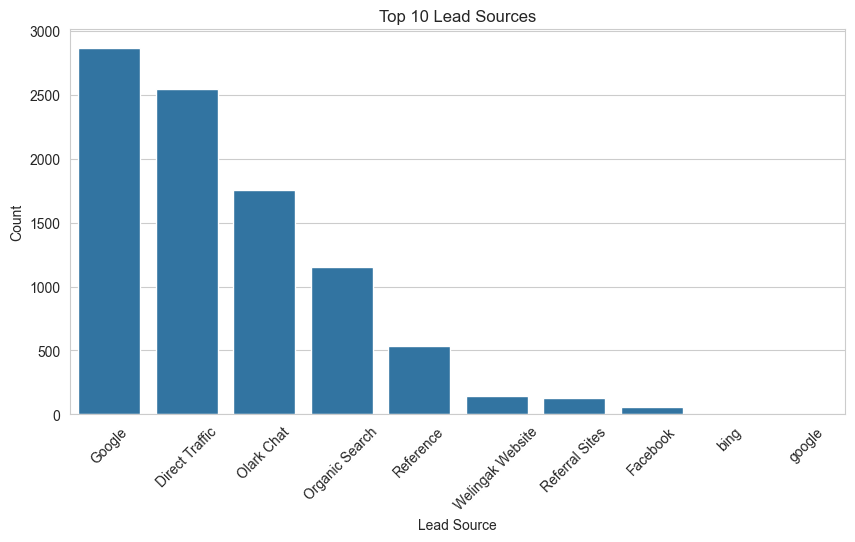

In [14]:
top_sources = df["Lead Source"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_sources.index,
    y=top_sources.values
)

plt.xticks(rotation=45)
plt.title("Top 10 Lead Sources")
plt.ylabel("Count")

plt.show()

### Interpretation

The majority of leads originate from a limited number of acquisition channels. Identifying the highest-performing channels allows marketing teams to focus resources on the sources most likely to generate qualified prospects.

## 3.4 Lead Origin Analysis

Lead Origin describes the mechanism through which a lead first entered the organization’s ecosystem.

Analyzing lead origin provides additional insight into customer acquisition behavior.

In [15]:
df["Lead Origin"].value_counts()

Lead Origin
Landing Page Submission    4886
API                        3580
Lead Add Form               718
Lead Import                  55
Quick Add Form                1
Name: count, dtype: int64

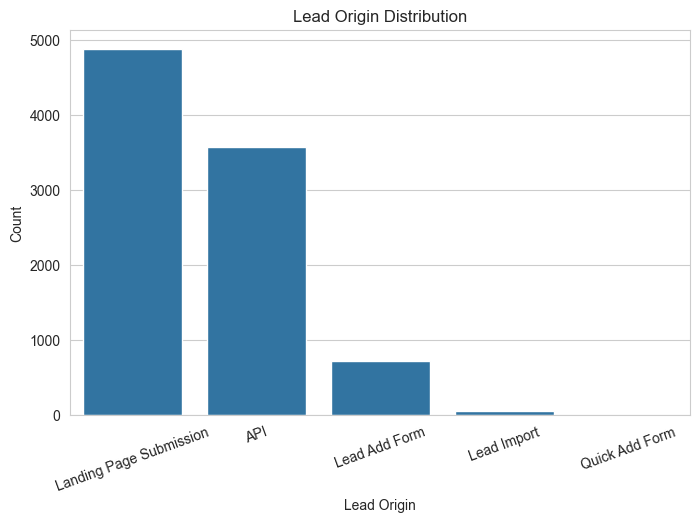

In [16]:
origin_counts = df["Lead Origin"].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=origin_counts.index,
    y=origin_counts.values
)

plt.xticks(rotation=20)

plt.title("Lead Origin Distribution")
plt.ylabel("Count")

plt.show()

### Interpretation

Lead origin analysis reveals how prospects initially engage with the company. This information helps businesses optimize lead acquisition strategies and evaluate the effectiveness of various customer touchpoints.

## 3.5 Website Engagement Analysis

Customer engagement metrics often provide strong predictive signals regarding purchase intent.

The following variables are analyzed:

- TotalVisits
- Total Time Spent on Website
- Page Views Per Visit

In [17]:
numerical_features = [
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit"
]

df[numerical_features].describe()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit
count,9103.000000,9240.000000,9103.000000
mean,3.445238,487.698268,2.362820
std,4.854853,548.021466,2.161418
min,0.000000,0.000000,0.000000
25%,1.000000,12.000000,1.000000
50%,3.000000,248.000000,2.000000
75%,5.000000,936.000000,3.000000
max,251.000000,2272.000000,55.000000


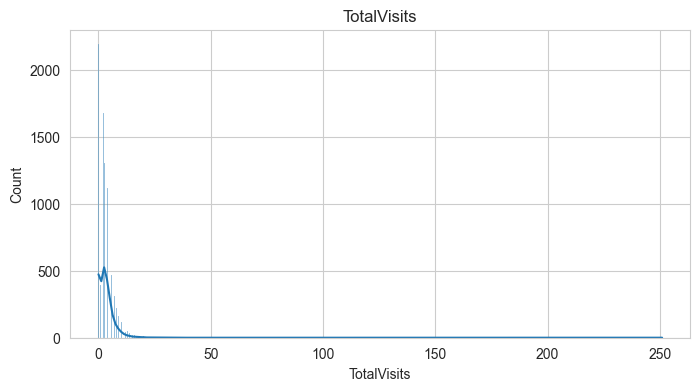

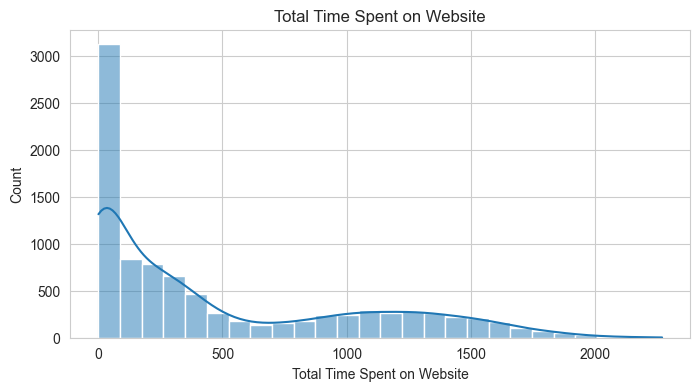

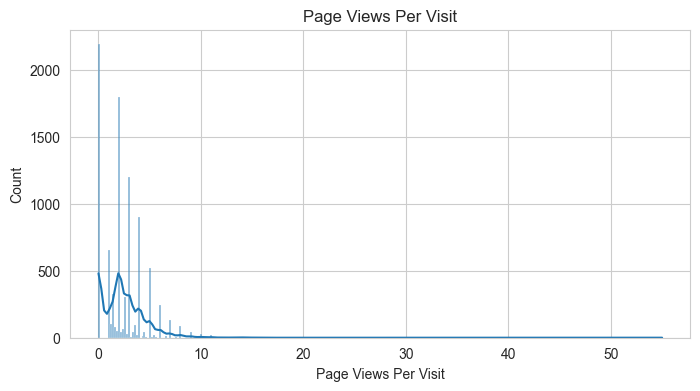

In [18]:
for feature in numerical_features:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[feature],
        kde=True
    )

    plt.title(feature)

    plt.show()

### Interpretation

Website engagement metrics exhibit varying distributions and may contain outliers. These variables are expected to play an important role in lead conversion prediction because they directly reflect customer interest and engagement.

# 4. Data Preparation

The objective of this phase is to prepare the dataset for machine learning by handling missing values, removing non-predictive attributes, encoding categorical variables, and preparing the target variable.

Proper data preparation is critical because machine learning models require clean, structured, and numerical inputs.

In [19]:
df.columns.tolist()

['Prospect ID',
 'Lead Number',
 'Lead Origin',
 'Lead Source',
 'Do Not Email',
 'Do Not Call',
 'Converted',
 'TotalVisits',
 'Total Time Spent on Website',
 'Page Views Per Visit',
 'Last Activity',
 'Country',
 'Specialization',
 'How did you hear about X Education',
 'What is your current occupation',
 'What matters most to you in choosing a course',
 'Search',
 'Magazine',
 'Newspaper Article',
 'X Education Forums',
 'Newspaper',
 'Digital Advertisement',
 'Through Recommendations',
 'Receive More Updates About Our Courses',
 'Tags',
 'Lead Quality',
 'Update me on Supply Chain Content',
 'Get updates on DM Content',
 'Lead Profile',
 'City',
 'Asymmetrique Activity Index',
 'Asymmetrique Profile Index',
 'Asymmetrique Activity Score',
 'Asymmetrique Profile Score',
 'I agree to pay the amount through cheque',
 'A free copy of Mastering The Interview',
 'Last Notable Activity']

## 4.1 Removing Non-Predictive Features

Several columns represent unique identifiers or administrative fields that do not contribute meaningful predictive information.

These features are removed to reduce noise and prevent data leakage.

In [20]:
drop_cols = [
    "Prospect ID",
    "Lead Number"
]

df = df.drop(columns=drop_cols)

print(df.shape)

(9240, 35)


## 4.2 Missing Value Treatment

Features with excessive missing values can negatively impact model performance.

Columns containing more than 40% missing values will be removed because they provide limited reliable information.

In [21]:
missing_percent = (
    df.isnull().mean() * 100
)

high_missing_cols = missing_percent[
    missing_percent > 40
].index

print(high_missing_cols.tolist())

['Lead Quality', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score']


### Missing Value Strategy

Several variables contained substantial missing values.

The Asymmetrique features were removed due to excessive missingness and limited business interpretability.

The Lead Quality feature was retained because it represents a business assessment of prospect quality and is expected to provide predictive value for conversion modeling.

Remaining missing values will be handled through categorical imputation and median-based numerical imputation.

In [22]:
cols_to_drop = [
    "Asymmetrique Activity Index",
    "Asymmetrique Profile Index",
    "Asymmetrique Activity Score",
    "Asymmetrique Profile Score"
]

df = df.drop(columns=cols_to_drop)

print("Dataset Shape After Column Removal:")
print(df.shape)

Dataset Shape After Column Removal:
(9240, 31)


In [23]:
missing_after_drop = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_after_drop.head(20)

Lead Quality                                     4767
Tags                                             3353
Lead Profile                                     2709
What matters most to you in choosing a course    2709
What is your current occupation                  2690
Country                                          2461
How did you hear about X Education               2207
Specialization                                   1438
City                                             1420
TotalVisits                                       137
Page Views Per Visit                              137
Last Activity                                     103
Lead Source                                        36
Update me on Supply Chain Content                   0
Lead Origin                                         0
Get updates on DM Content                           0
Through Recommendations                             0
I agree to pay the amount through cheque            0
A free copy of Mastering The

## 4.3 Missing Value Imputation

Machine learning models cannot directly process missing values.

Categorical features will be imputed using the value "Unknown" while numerical features will be imputed using the median value of each column.

In [24]:
categorical_cols = df.select_dtypes(
    include="object"
).columns

print("Number of Categorical Columns:")
print(len(categorical_cols))

Number of Categorical Columns:
27


In [25]:
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

In [26]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Number of Numerical Columns:")
print(len(numerical_cols))

Number of Numerical Columns:
4


In [27]:
for col in numerical_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [28]:
print("Remaining Missing Values:")
print(df.isnull().sum().sum())

Remaining Missing Values:
0


### Data Preparation Summary

The dataset was cleaned by removing highly incomplete features and imputing remaining missing values.

Categorical variables were assigned an "Unknown" category when information was unavailable, while numerical variables were imputed using median values to minimize the impact of outliers.

The resulting dataset is now suitable for feature engineering and machine learning model development.

# 5. Feature Engineering and Encoding

Machine learning algorithms require numerical inputs. Therefore, categorical variables must be transformed into a machine-readable format before model training.

In this phase, the target variable is separated, categorical features are encoded, and the dataset is prepared for model development.

In [29]:
y = df["Converted"]

X = df.drop(
    columns=["Converted"]
)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (9240, 30)
y Shape: (9240,)


## 5.1 Categorical Variable Identification

The dataset contains both numerical and categorical variables.

Categorical variables must be encoded into numerical representations before they can be processed by machine learning algorithms.

In [30]:
categorical_cols = X.select_dtypes(
    include="object"
).columns

print("Categorical Features:")
print(categorical_cols.tolist())

print("\nCount:")
print(len(categorical_cols))

Categorical Features:
['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Lead Quality', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']

Count:
27


In [31]:
numerical_cols = X.select_dtypes(
    exclude="object"
).columns

print("Numerical Features:")
print(len(numerical_cols))

Numerical Features:
3


## 5.2 One-Hot Encoding

One-hot encoding converts categorical values into binary indicator variables.

This approach prevents machine learning models from incorrectly assuming ordinal relationships between categories.

In [32]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded Dataset Shape:")
print(X_encoded.shape)

Encoded Dataset Shape:
(9240, 189)


### Feature Engineering Summary

Categorical variables were transformed using one-hot encoding, resulting in a fully numerical dataset suitable for machine learning.

The encoded feature matrix will be used for model training and evaluation.

# 6. Train-Test Split

To evaluate model performance fairly, the dataset is divided into training and testing subsets.

The training set is used for learning patterns while the testing set is used to evaluate generalization performance on unseen data.

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (7392, 189)
Testing Set: (1848, 189)


### Train-Test Split Summary

An 80/20 split was selected to balance model training and evaluation.

Stratified sampling was applied to preserve the distribution of converted and non-converted leads in both subsets.

# 7. Modeling

Three machine learning models are evaluated in this project:

1. Logistic Regression
2. Random Forest
3. XGBoost

The objective is to compare performance and identify the model that best predicts lead conversion.

## 7.1 Logistic Regression

Logistic Regression is a widely used baseline classification algorithm. It provides a simple and interpretable approach for predicting binary outcomes.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [36]:
log_model = LogisticRegression(
    max_iter=2000
)

log_model.fit(
    X_train,
    y_train
)

c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [37]:
y_pred_log = log_model.predict(
    X_test
)

log_accuracy = accuracy_score(
    y_test,
    y_pred_log
)

log_precision = precision_score(
    y_test,
    y_pred_log
)

log_recall = recall_score(
    y_test,
    y_pred_log
)

log_f1 = f1_score(
    y_test,
    y_pred_log
)

print("Accuracy :", round(log_accuracy,4))
print("Precision:", round(log_precision,4))
print("Recall   :", round(log_recall,4))
print("F1 Score :", round(log_f1,4))

Accuracy : 0.928
Precision: 0.9239
Recall   : 0.8862
F1 Score : 0.9047


In [38]:
print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1136
           1       0.92      0.89      0.90       712

    accuracy                           0.93      1848
   macro avg       0.93      0.92      0.92      1848
weighted avg       0.93      0.93      0.93      1848



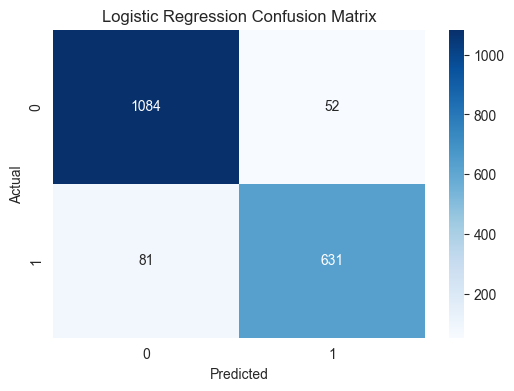

In [39]:
cm = confusion_matrix(
    y_test,
    y_pred_log
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Logistic Regression Interpretation

Logistic Regression provides a baseline benchmark for lead conversion prediction. Its results establish a reference point against which more sophisticated models can be compared.

## 7.2 Random Forest

Random Forest is an ensemble learning method that combines multiple decision trees to improve predictive performance and reduce overfitting.

In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
y_pred_rf = rf_model.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

print("Accuracy :", round(rf_accuracy,4))
print("Precision:", round(rf_precision,4))
print("Recall   :", round(rf_recall,4))
print("F1 Score :", round(rf_f1,4))

Accuracy : 0.9302
Precision: 0.917
Recall   : 0.9003
F1 Score : 0.9086


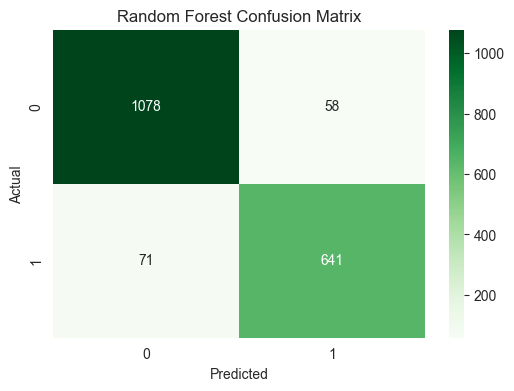

In [43]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 7.3 XGBoost

XGBoost is a gradient boosting algorithm that builds decision trees sequentially, allowing each new tree to correct errors made by previous trees.

It is widely used in industry for structured tabular datasets and frequently achieves state-of-the-art predictive performance.

In [44]:
%pip install xgboost -q

Note: you may need to restart the kernel to use updated packages.


In [45]:
from xgboost import XGBClassifier

In [46]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [47]:
y_pred_xgb = xgb_model.predict(
    X_test
)

xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb
)

print("Accuracy :", round(xgb_accuracy,4))
print("Precision:", round(xgb_precision,4))
print("Recall   :", round(xgb_recall,4))
print("F1 Score :", round(xgb_f1,4))

Accuracy : 0.9389
Precision: 0.926
Recall   : 0.9143
F1 Score : 0.9201


# 8. Model Evaluation and Comparison

Multiple machine learning algorithms were evaluated to determine the most effective approach for lead conversion prediction.

Model performance was assessed using Accuracy, Precision, Recall, and F1 Score.

In [50]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        log_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        log_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        log_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        log_f1,
        rf_f1,
        xgb_f1
    ]
})

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9280,0.9239,0.8862,0.9047
1,Random Forest,0.9302,0.9170,0.9003,0.9086
2,XGBoost,0.9389,0.9260,0.9143,0.9201


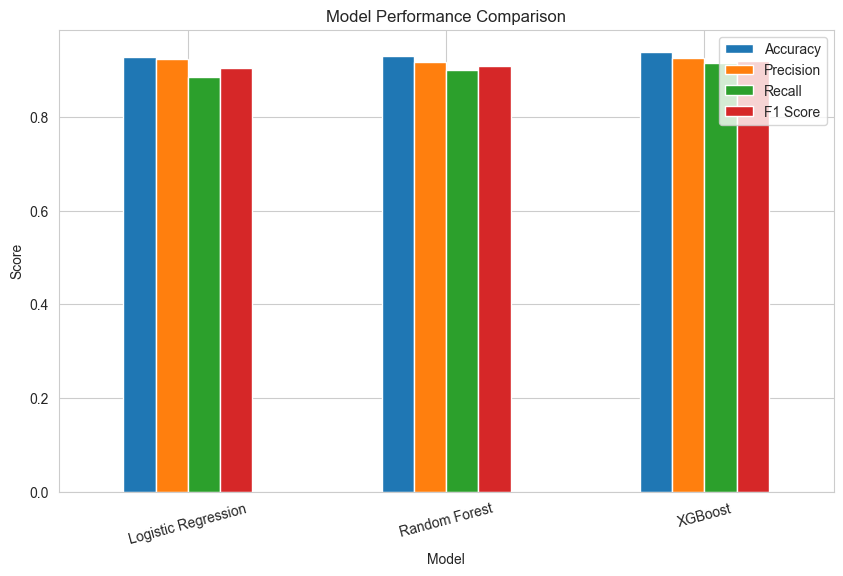

In [51]:
comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")

plt.xticks(rotation=15)

plt.show()

### Model Selection

Among the evaluated models, XGBoost achieved the highest overall performance across all evaluation metrics.

The model delivered:

- Accuracy: 93.89%
- Precision: 92.60%
- Recall: 91.43%
- F1 Score: 92.01%

Given its superior predictive performance, XGBoost was selected as the final production model for lead qualification and conversion prediction.

## 8.1 Feature Importance Analysis

Feature importance analysis provides insight into which factors most strongly influence lead conversion outcomes.

Understanding these drivers helps business stakeholders improve lead acquisition and qualification strategies.

In [52]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
148,Tags_Will revert after reading the email,0.353489
130,Tags_Closed by Horizzon,0.103682
21,Lead Source_Welingak Website,0.051891
4,Lead Origin_Lead Add Form,0.048379
122,What matters most to you in choosing a course_...,0.043045
146,Tags_Unknown,0.038664
185,Last Notable Activity_SMS Sent,0.035223
138,Tags_Lost to EINS,0.034265
129,Tags_Busy,0.024783
142,Tags_Ringing,0.019378


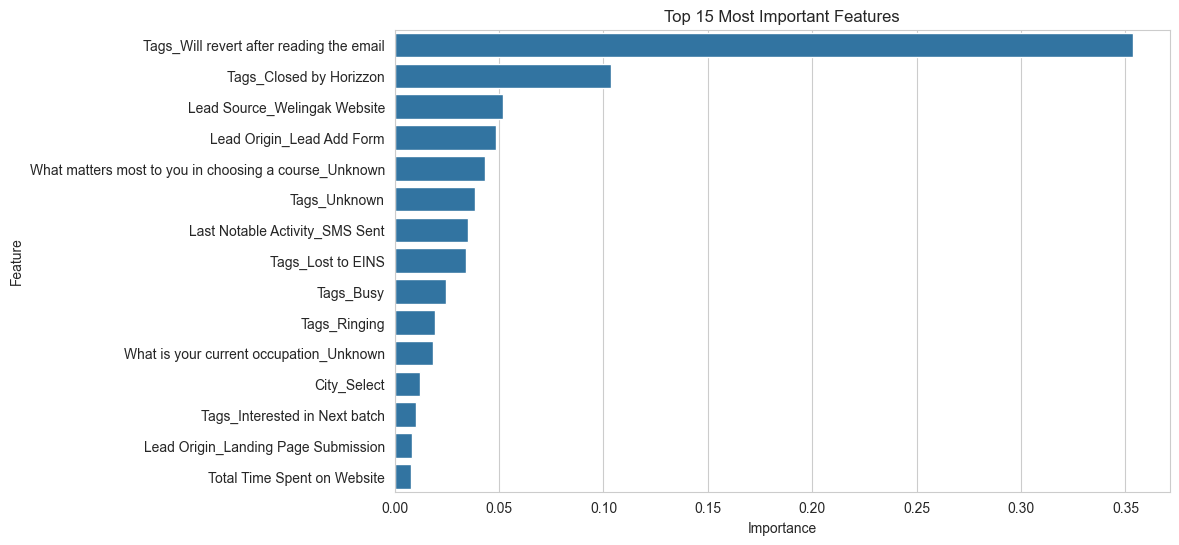

In [53]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features")

plt.show()

### Feature Importance Interpretation

The feature importance analysis revealed that lead engagement indicators, acquisition channels, lead status tags, and website behavior metrics were among the strongest predictors of conversion.

Several sales-process-related attributes exhibited strong predictive power, suggesting that customer engagement throughout the lead lifecycle significantly influences conversion outcomes.

Website engagement metrics, including total time spent on the website, also emerged as important predictors, reinforcing the importance of digital interaction behavior in lead qualification.

# 9. Model Deployment Preparation

After selecting the best-performing model, the model is serialized and saved for deployment.

This enables integration with external applications such as conversational AI assistants, CRM systems, and sales automation platforms.

In [54]:
import pickle
from pathlib import Path

Path("../models").mkdir(
    exist_ok=True
)

pickle.dump(
    xgb_model,
    open(
        "../models/lead_scoring_model.pkl",
        "wb"
    )
)

print("Model Saved Successfully")

Model Saved Successfully


In [55]:
import os

print(
    os.path.exists(
        "../models/lead_scoring_model.pkl"
    )
)

True


# 10. Deployment Strategy

The machine learning model developed in this project can be integrated directly into the AutoStream LeadIQ conversational AI platform.

Deployment Architecture:

Website Visitor
→ Conversational AI Assistant
→ Lead Information Collection
→ Lead Scoring Model (XGBoost)
→ Lead Priority Classification
→ CRM / Sales Team

When a visitor interacts with the chatbot, the system captures engagement information and prospect details. These attributes are passed to the lead scoring model, which predicts conversion probability and assigns a lead priority score.

High-priority leads can be routed immediately to sales representatives, while lower-priority leads can enter automated nurturing workflows.

### Production Considerations

Potential deployment options include:

- Streamlit Cloud
- AWS EC2
- AWS ECS
- Azure App Service
- Google Cloud Run

The current architecture supports both real-time lead scoring and batch lead qualification workflows.

The solution can also be integrated with CRM systems such as Salesforce, HubSpot, or Zoho CRM.

# 11. Ethical Considerations

Several ethical considerations must be addressed when deploying AI-powered lead qualification systems.

- Customer privacy must be protected.
- Personally identifiable information should be securely stored.
- Lead prioritization should not create unfair bias toward specific demographic groups.
- Model predictions should support, rather than replace, human decision-making.

Regular monitoring and retraining should be implemented to ensure continued fairness and performance.

# 12. Conclusions and Recommendations

This project developed an AI-powered lead qualification system capable of predicting lead conversion using behavioral, demographic, and marketing-related features.

Three machine learning models were evaluated:

- Logistic Regression
- Random Forest
- XGBoost

Among the evaluated approaches, XGBoost achieved the strongest overall performance with:

- Accuracy: 93.89%
- Precision: 92.60%
- Recall: 91.43%
- F1 Score: 92.01%

The findings demonstrate that machine learning can significantly improve lead prioritization and support more efficient sales operations.

Future enhancements may include CRM integration, automated retraining pipelines, conversational lead scoring, and real-time deployment within customer-facing AI assistants.

# References

Scikit-learn Documentation:
https://scikit-learn.org/

XGBoost Documentation:
https://xgboost.readthedocs.io/

Pandas Documentation:
https://pandas.pydata.org/

Seaborn Documentation:
https://seaborn.pydata.org/

Matplotlib Documentation:
https://matplotlib.org/

Lead Scoring Dataset:
Kaggle Lead Scoring Dataset

## Asset collection

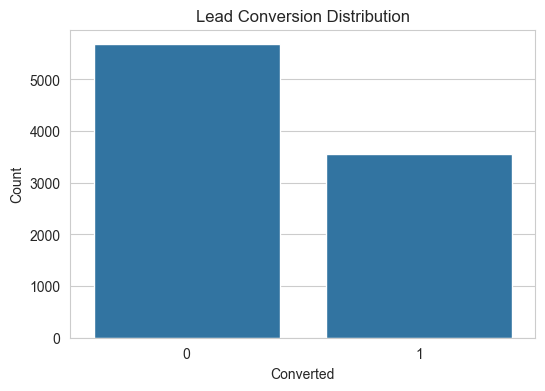

In [60]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Converted"
)

plt.title("Lead Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Count")

plt.savefig(
    "../assets/conversion_distribution.png",
    bbox_inches="tight"
)

plt.show()

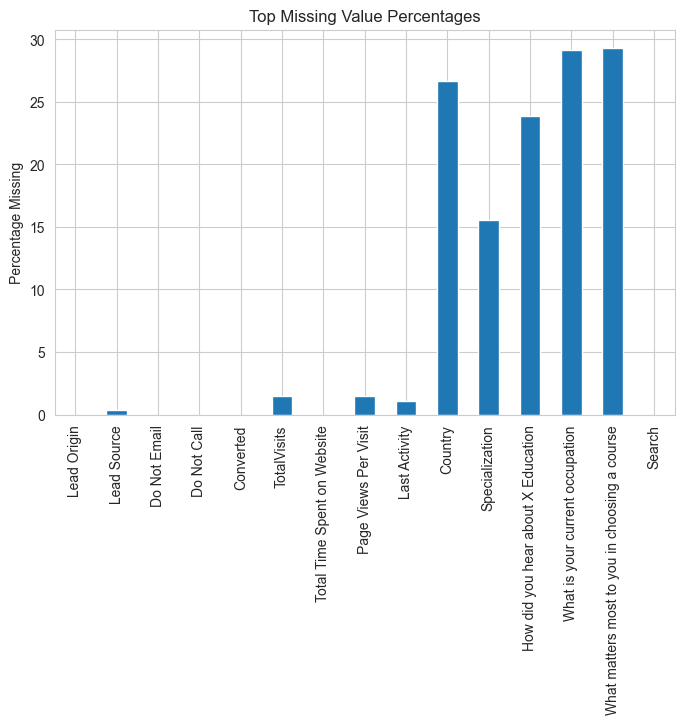

In [61]:
missing_percent.head(15).plot(
    kind="bar"
)

plt.title("Top Missing Value Percentages")
plt.ylabel("Percentage Missing")

plt.savefig(
    "../assets/missing_values.png",
    bbox_inches="tight"
)

plt.show()

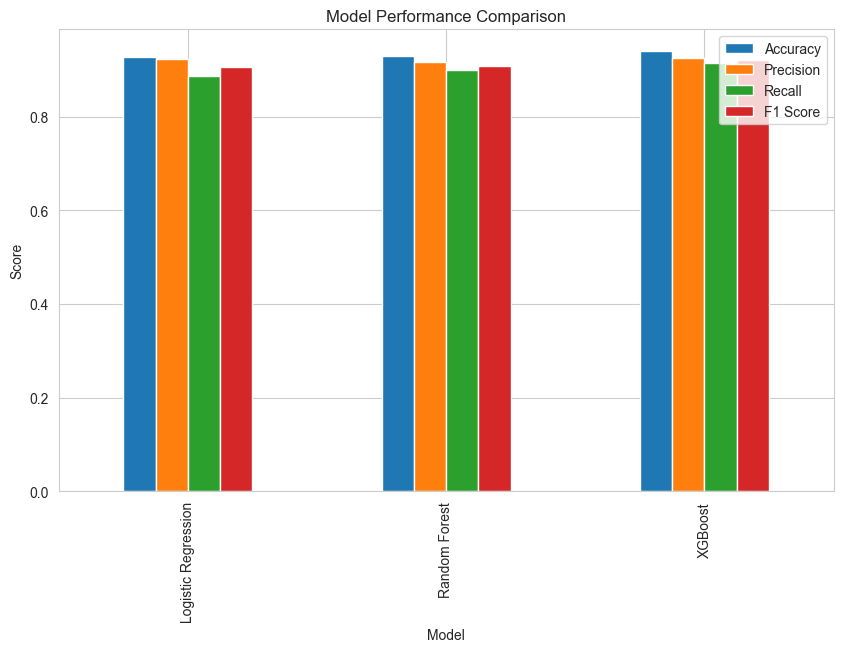

In [62]:
comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")

plt.savefig(
    "../assets/model_comparison.png",
    bbox_inches="tight"
)

plt.show()

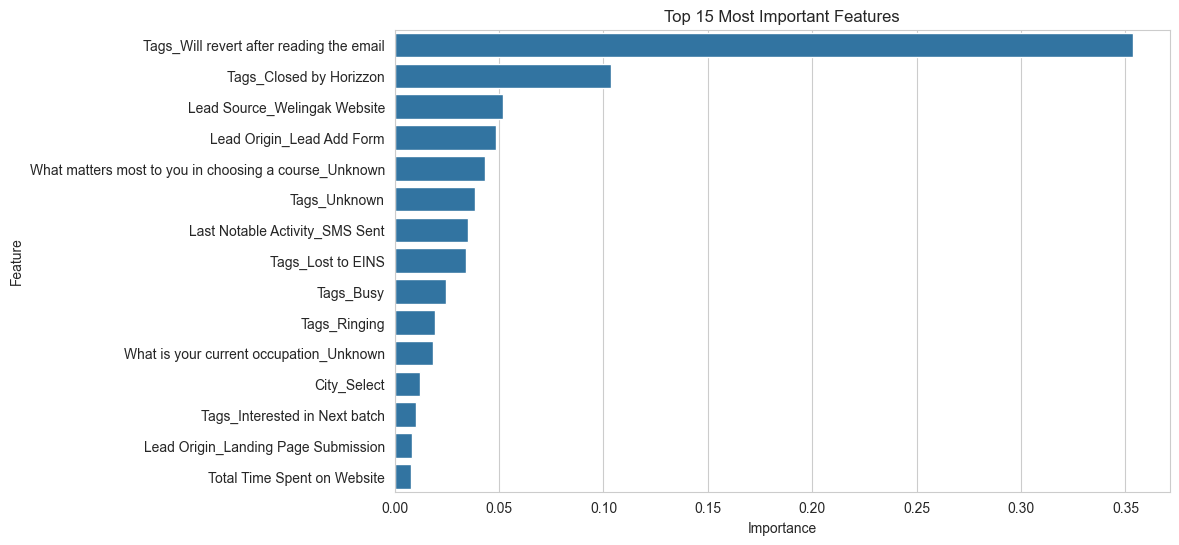

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features")

plt.savefig(
    "../assets/feature_importance.png",
    bbox_inches="tight"
)

plt.show()